# Initial Setup

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.metrics import (

    roc_auc_score,
    accuracy_score,
    f1_score,
    log_loss,
    roc_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

contract = pd.read_csv('../data/contract.csv')

internet = pd.read_csv('../data/internet.csv')

personal = pd.read_csv('../data/personal.csv')

phone = pd.read_csv('../data/phone.csv')

# Data Preprocessing 

In [359]:
df = (contract.merge(internet, on="customerID", how="left")
              .merge(personal, on="customerID", how="left")
              .merge(phone, on="customerID", how="left"))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
 8   InternetService   5517 non-null   str    
 9   OnlineSecurity    5517 non-null   str    
 10  OnlineBackup      5517 non-null   str    
 11  DeviceProtection  5517 non-null   str    
 12  TechSupport       5517 non-null   str    
 13  StreamingTV       5517 non-null   str    
 14  StreamingMovies   5517 non-null   str    
 15  gender            7043 non-null   str    
 16  SeniorCitizen     7043 non-null   int64  
 17  Partne

Las tablas fueron unidas mediante la clave "customerID".
Se utilizó una unión de tipo "left", tomando la tabla "contract" como base,
lo que garantiza que se conserven todos sus registros, incluso si no existe información
correspondiente en las tablas "internet", "personal" o "phone".

In [360]:
# Column Standardization.

def standarize_column_names(df):
    new_columns = []

    for col in df.columns:
        new_col = ""
        for j, char in enumerate(col):
            if char.isupper() and j != 0 and col[j-1].islower():
                new_col += "_" + char.lower()
            else:
                new_col += char.lower()
        new_columns.append(new_col)

    return new_columns


df.columns = standarize_column_names(df)

df.columns.tolist()

['customer_id',
 'begin_date',
 'end_date',
 'type',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'multiple_lines']

# Data Quality Assessment and Feature Engineering

In [361]:
# Reviewing duplicates in the whole dataset.

print(f"Duplicate rows in the dataset: {df.duplicated().sum()}")

Duplicate rows in the dataset: 0


In [362]:
# Reviewing duplicates in the customer_id column.

print(f"Duplicate customer IDs: {df['customer_id'].duplicated().sum()}")

Duplicate customer IDs: 0


In [ ]:
# Reviewing missing values in the dataset.

columns_nan = df.isna().sum().sort_values(ascending=False)
columns_nan[columns_nan > 0]

internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
streaming_tv         1526
streaming_movies     1526
tech_support         1526
multiple_lines        682
dtype: int64

In [364]:
# Verifying consistency of customer IDs across datasets.

contract_ids = set(contract['customerID'])

summary = pd.DataFrame({
    'Check': [
        'Contract == Personal',
        'Internet ⊆ Contract',
        'Phone ⊆ Contract',
        'Missing Internet customers',
        'Missing Phone customers'
    ],
    'Result': [
        contract_ids == set(personal['customerID']),
        set(internet['customerID']).issubset(contract_ids),
        set(phone['customerID']).issubset(contract_ids),
        len(contract_ids - set(internet['customerID'])),
        len(contract_ids - set(phone['customerID']))
    ]
})

display(summary)

,Check,Result
0,Contract == Personal,True
1,Internet ⊆ Contract,True
2,Phone ⊆ Contract,True
3,Missing Internet customers,1526
4,Missing Phone customers,682


Al analizar la estructura de los datasets, se confirmó que todas las columnas con valores faltantes provienen exclusivamente de las tablas de servicios (internet y phone). La consistencia en el número de valores faltantes (1526 en todas las variables relacionadas con internet y 682 en multiple_lines) indica que no se trata de datos faltantes al azar, sino de un patrón estructural.

Todos los conjuntos de datos son consistentes en cuanto al customerID. El dataset personal contiene la totalidad de los clientes, mientras que los de internet y phone son subconjuntos; esto indica que las entradas faltantes corresponden a clientes que no utilizan dichos servicios, en lugar de ser inconsistencias en los datos.

En consecuencia, estos valores se imputan como "No", indicando explícitamente que el cliente no dispone de dicho servicio.

In [365]:
# Fill missing values with 'No', indicating absence of service and ensuring consistency with binary encoding.

columns_nan = columns_nan[columns_nan > 0].index.tolist()

for col in columns_nan:
    df[col] = df[col].fillna('No')

In [366]:
# Reviewing missing values after filling them with 'No'.

df.isna().sum().sort_values(ascending=False)

customer_id          0
begin_date           0
end_date             0
type                 0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
gender               0
senior_citizen       0
partner              0
dependents           0
multiple_lines       0
dtype: int64

In [367]:
# Dropping the 'customer_id' column as it doesn't add predictive value to the model and is not needed for analysis.

df = df.drop('customer_id', axis=1)

df.columns.tolist()

['begin_date',
 'end_date',
 'type',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'multiple_lines']

In [368]:
# Verifying consistency between 'internet_service' and related service columns.

internet_cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]

inconsistencies = (
    (df['internet_service'] == 'No') &
    (df[internet_cols] == 'Yes').any(axis=1)
    )

print(f"Inconsistencies found: {inconsistencies.sum()}")


Inconsistencies found: 0


### Feature Engineering 🧩

In [369]:
# Convert key columns to appropriate data types.

df['begin_date'] = pd.to_datetime(df['begin_date'], errors='coerce')
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')


df['churn'] = (df['end_date'] != 'No').astype(int)

# Define reference date (observation cutoff)

reference_date = pd.Timestamp(df['begin_date'].max()) + pd.Timedelta(days=1)

# Creating tenure-based features to capture customer lifetime and enable temporal analysis.
# These new features can be potential indirect leakage, therefore that will be addressed in the modeling module

df['start_month'] = df['begin_date'].dt.month
df['start_year'] = df['begin_date'].dt.year

df = df.drop(['end_date', 'total_charges'], axis=1)

En esta etapa se realizó la preparación de los datos y la ingeniería de características inicial. Se definió la variable objetivo churn a partir de end_date, y se transformaron las variables a sus tipos de datos correspondientes para asegurar consistencia en el análisis.

Adicionalmente, se generaron variables derivadas de begin_date, como start_month y start_year con el objetivo de capturar posibles patrones temporales en la adquisición de clientes que pudieran influir en el churn.

En esta fase no se incluyeron variables derivadas de la antigüedad del cliente (tenure), ya que su cálculo depende de una fecha de referencia que, si se define de manera global, puede introducir fuga de información. En su lugar, estas variables serán generadas posteriormente durante la fase de modelado utilizando un enfoque de división temporal (time-based split), donde la antigüedad se calculará de forma consistente respecto al momento de observación de cada subconjunto (entrenamiento y prueba).

La variable begin_date se mantiene en el conjunto de datos exclusivamente con fines de ingeniería de características en etapas posteriores, pero no será utilizada directamente en el modelado o se analizará exhaustivamente, dado que su información ya está parcialmente representada en las variables derivadas.

Finalmente, se eliminaron las variables end_date y total_charges para evitar fuga de información y redundancia en los datos.

In [370]:
# Identifying binary and categorical columns for appropriate encoding strategies in the modeling phase.

binary_columns = []
categorical_columns = []


for col in df.columns:
    if df[col].nunique() == 2:
        binary_columns.append(col)
    else:
        categorical_columns.append(col)


max_len = max(len(binary_columns), len(categorical_columns))

summary = pd.DataFrame({
    'Binary Columns': binary_columns + [''] * (max_len - len(binary_columns)),
    'Categorical Columns': categorical_columns + [''] * (max_len - len(categorical_columns))
})

display(summary)

,Binary Columns,Categorical Columns
0,paperless_billing,begin_date
1,online_security,type
2,online_backup,payment_method
3,device_protection,monthly_charges
4,tech_support,internet_service
5,streaming_tv,start_month
6,streaming_movies,start_year
7,gender,
8,senior_citizen,
9,partner,


In [371]:
# Analyzing the distribution of the target variable 'churn' to understand class balance and inform modeling strategies.

churn_dist = df['churn'].value_counts(normalize=True)

print(f"No churn (0): {churn_dist[0]:.1%}")
print(f"Churned  (1): {churn_dist[1]:.1%}")

No churn (0): 73.5%
Churned  (1): 26.5%


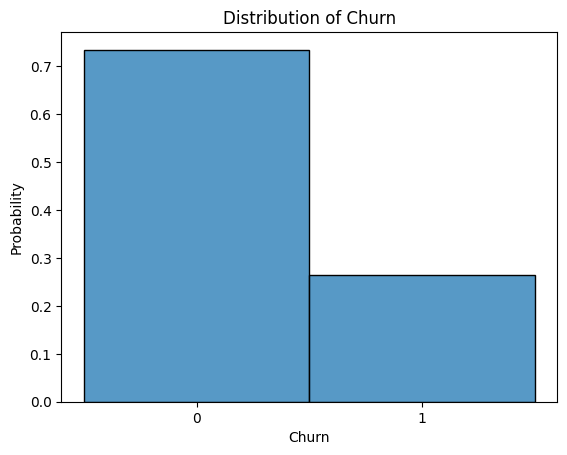

In [372]:
# Visualizing the distribution of the target variable 'churn' to assess class balance and inform modeling strategies.

sns.histplot(df['churn'], stat='probability', discrete=True)
plt.xlabel('Churn')
plt.ylabel('Probability')
plt.xticks([0, 1])
plt.title('Distribution of Churn')
plt.show()

La variable objetivo muestra un desequilibrio de clases moderado, con aproximadamente 73% de clientes que no abandonan y 27% que abandonan. Aunque este desequilibrio no es severo, es importante considerar métricas de evaluación más allá de la precisión, como precision, recall y F1-score, para asegurar que el modelo funcione bien en la identificación de clientes que abandonan.



In [373]:
# Analyzing the distribution of binary features to understand their balance and potential impact on the model.

binary_distributions = []

for col in binary_columns:
    dist = df[col].value_counts(normalize=True)
    dist = dist.sort_index()
    dist = dist.map(lambda x: f"{x:.1%}")


    binary_distributions.append(dist.values)

df_binary_dist = pd.DataFrame(
    binary_distributions,
    columns=['Class 0', 'Class 1'],
    index=binary_columns
)

df_binary_dist.sort_values('Class 1', ascending=False)

,Class 0,Class 1
paperless_billing,40.8%,59.2%
gender,49.5%,50.5%
partner,51.7%,48.3%
multiple_lines,57.8%,42.2%
streaming_movies,61.2%,38.8%
streaming_tv,61.6%,38.4%
online_backup,65.5%,34.5%
device_protection,65.6%,34.4%
dependents,70.0%,30.0%
tech_support,71.0%,29.0%


La distribución de las características binarias varía entre variables, desde casi completamente equilibradas (por ejemplo, 'genre') hasta moderadamente desequilibradas (por ejemplo, 'senior_citizen'). A pesar de esta variación, ninguna característica muestra una asimetría extrema que limitaría significativamente su utilidad. Dado que incluso las características binarias desequilibradas pueden proporcionar valor predictivo cuando se combinan con otras, todas las variables se conservan para el modelado, y su importancia será evaluada durante el entrenamiento del modelo.

In [374]:
# Visualizing unique value counts and data types for multi-class columns.

categorical_unique = []

for col in categorical_columns:
    dist = df[col].nunique()
    dtype = df[col].dtypes
    categorical_unique.append([dist, dtype])

df_categorical_dist = pd.DataFrame(
    categorical_unique,
    columns=['Unique Values', 'Data Type'],
    index=categorical_columns
)

df_categorical_dist.sort_values('Unique Values', ascending=False)

,Unique Values,Data Type
monthly_charges,1585,float64
begin_date,77,datetime64[us]
start_month,12,int32
start_year,8,int32
payment_method,4,str
type,3,str
internet_service,3,str


El análisis de características multi clase destaca diferencias claras en la cardinalidad impulsadas por el tipo de datos y el significado de las características. Las variables continuas como monthly_charges o begin_date naturalmente presentan alta cardinalidad, lo cual es esperado y no requiere acción correctiva. En contraste, las características categóricas verdaderas mantienen un número manejable de niveles, haciéndolas apropiadas para estrategias de codificación.

In [375]:
# Analyzing the distribution of multi-class features.

for col in df[categorical_columns].select_dtypes(include=['string', 'category', 'int32']).columns:
    dist = df[col].value_counts(normalize=True)
    dist = dist.sort_index()
    dist = dist.map(lambda x: f"{x:.1%}")

    data_dist = pd.DataFrame(dist.values, columns=['Distribution'], index=dist.index)
    data_dist.index.name = None
    print(f"\nDistribution of the {col} column:")
    display(data_dist)


Distribution of the type column:


,Distribution
Month-to-month,55.0%
One year,20.9%
Two year,24.1%



Distribution of the payment_method column:


,Distribution
Bank transfer (automatic),21.9%
Credit card (automatic),21.6%
Electronic check,33.6%
Mailed check,22.9%



Distribution of the internet_service column:


,Distribution
DSL,34.4%
Fiber optic,44.0%
No,21.7%



Distribution of the start_month column:


,Distribution
1,8.8%
2,11.4%
3,8.4%
4,7.3%
5,7.0%
6,7.4%
7,7.4%
8,7.6%
9,8.8%
10,8.5%



Distribution of the start_year column:


,Distribution
2013,0.1%
2014,19.1%
2015,12.1%
2016,10.8%
2017,12.0%
2018,14.6%
2019,27.8%
2020,3.5%


El análisis de distribución de las variables multiclase revela patrones relevantes para el modelado. En type, más de la mitad de los clientes (55%) tienen contratos mes a mes, lo cual es significativo, ya que este tipo de contrato implica menor compromiso y mayor probabilidad de cancelación. En payment_method, Electronic check domina con 33.6%, mientras que los demás métodos presentan una distribución relativamente equilibrada.

En internet_service, Fiber optic representa el segmento más grande con 44% de los clientes, seguido por DSL con 34.4% y clientes sin servicio de internet con 21.7%.

Por otro lado, las variables temporales derivadas de begin_date, como start_month y start_year, no presentan distribuciones extremas. En particular, start_month muestra una distribución bastante uniforme, lo que sugiere baja estacionalidad en la adquisición de clientes, mientras que start_year refleja diferencias entre cohortes que podrían influir indirectamente en el comportamiento del churn.

En general, no se observan desbalances severos que requieran tratamiento previo al modelado. Sin embargo, algunas categorías dominantes, como los contratos mes a mes y el servicio de fibra óptica, podrían tener una influencia significativa en la predicción del churn.

# Exploratory Data Analysis (EDA)

### Target Variable Overview

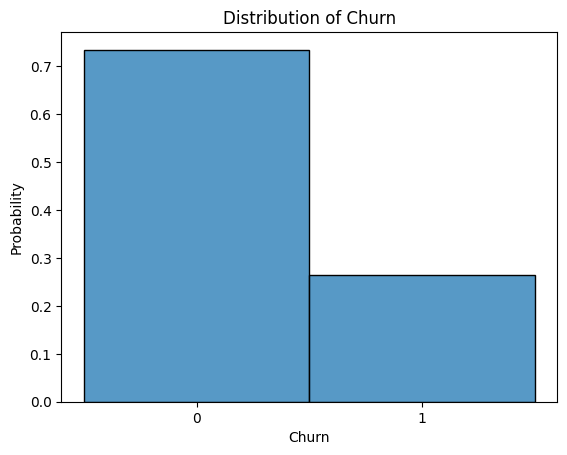

In [376]:
sns.histplot(df['churn'], stat='probability', discrete=True)
plt.xlabel('Churn')
plt.ylabel('Probability')
plt.xticks([0, 1])
plt.title('Distribution of Churn')
plt.show()

Como se observó previamente, la variable objetivo muestra un desequilibrio de clases moderado (~73% no abandono vs ~27% abandono), lo cual será considerado al interpretar los resultados.

### Impact of Internet Services on Churn

In [377]:
# Analyzing the relationship between binary internet service features and churn to identify potential predictors and inform feature selection for modeling.

internet_columns = set(standarize_column_names(internet)) & set(df.columns)
binary_internet_columns = internet_columns & set(binary_columns)

internet_binary_info = []

for col in binary_internet_columns:
    dist = df.groupby(col)['churn'].mean()
    dist = dist.reindex(['No', 'Yes'])
    dist_diff = dist['Yes'] - dist['No']

    internet_binary_info.append([
        dist['Yes'],
        dist['No'],
        dist_diff
    ])


data_internet_binary_info = pd.DataFrame(
    internet_binary_info,
    columns=['Service Activated', 'Service Not Activated', 'Diff'],
    index=list(binary_internet_columns)
)

data_internet_service = pd.DataFrame(df.groupby('internet_service')[
                                     'churn'].mean().sort_values(ascending=False).map('{:.1%}'.format)).rename(columns={'churn': 'Internet Service'})

data_internet_service.index.name = None


print("Churn rates for binary internet service features: \n")
display(data_internet_binary_info.sort_values(
    'Diff', ascending=False).map(lambda x: f"{x:.1%}"))


print("\nChurn rates by internet service type:\n")
display(data_internet_service)

Churn rates for binary internet service features: 



,Service Activated,Service Not Activated,Diff
streaming_tv,30.1%,24.3%,5.7%
streaming_movies,29.9%,24.4%,5.6%
device_protection,22.5%,28.7%,-6.1%
online_backup,21.5%,29.2%,-7.6%
tech_support,15.2%,31.2%,-16.0%
online_security,14.6%,31.3%,-16.7%



Churn rates by internet service type:



,Internet Service
Fiber optic,41.9%
DSL,19.0%
No,7.4%


Los resultados destacan que la ausencia de servicios clave, particularmente online_security y tech_support, está asociada con tasas de abandono sustancialmente más altas, indicando que estas características pueden actuar como impulsores de retención. Por el contrario, los clientes que se suscriben a estos servicios tienen significativamente menos probabilidad de abandonar.

Además, los clientes con servicio de Fiber optic presentan la tasa de abandono más alta con un 42%, seguidos por los clientes con DSL en un 19%. Los clientes sin servicio de internet apenas alcanzan un 7% de abandono. Esto sugiere que el tipo de servicio de internet es una variable con alto poder predictivo, y que los clientes de Fiber optic representan el segmento de mayor riesgo.

La magnitud de las diferencias observadas entre características sugiere que las variables relacionadas con servicios probablemente serán predictores fuertes en el modelo de abandono.

### Impact of Contract details on Churn

In [378]:
# Identifying which columns in the 'contract' dataset are binary and which are non-binary.

contract_columns = set(standarize_column_names(contract)) & set(df.columns)

variables_nunique = []

for col in contract_columns:
    variables_nunique.append([df[col].nunique(), df[col].dtypes])

df_contract_info = pd.DataFrame(variables_nunique, columns=['Unique Values', 'Data Type'], index=list(contract_columns))

df_contract_info.sort_values('Unique Values', ascending=False)

,Unique Values,Data Type
monthly_charges,1585,float64
begin_date,77,datetime64[us]
payment_method,4,str
type,3,str
paperless_billing,2,str


In [379]:
# Analyzing the relationship between categorical contract features and churn.

categorical_contract = df[list(contract_columns)].select_dtypes(include='str')

for col in categorical_contract.columns:
    dist = df.groupby(col)['churn'].mean()
    dist = dist.sort_index()
    dist = dist.map(lambda x: f"{x:.1%}")

    display_df = pd.DataFrame(dist.values, columns=['Proportion'], index=dist.index)

    display_df.index.name = None

    print(f"\nChurn rate for {col}:")
    display(display_df)



Churn rate for type:


,Proportion
Month-to-month,42.7%
One year,11.3%
Two year,2.8%



Churn rate for payment_method:


,Proportion
Bank transfer (automatic),16.7%
Credit card (automatic),15.2%
Electronic check,45.3%
Mailed check,19.1%



Churn rate for paperless_billing:


,Proportion
No,16.3%
Yes,33.6%


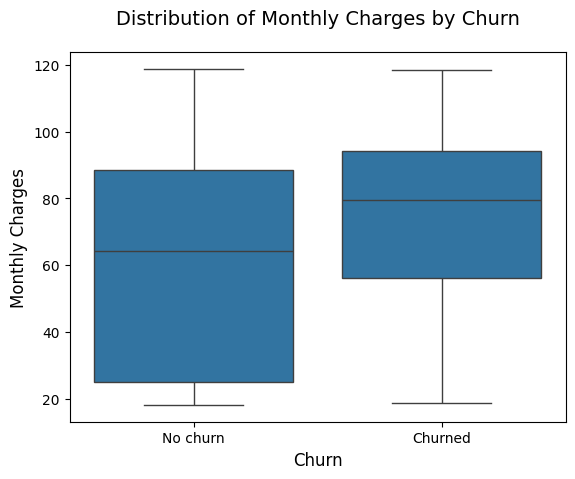

In [380]:
# Visualising the distribution of monthly charges by churn status.

ax = sns.boxplot(x="churn", y="monthly_charges", data=df)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No churn", "Churned"])

plt.title('Distribution of Monthly Charges by Churn', fontsize=14, pad=20)
plt.ylabel("Monthly Charges", fontsize=12)
plt.xlabel("Churn", fontsize=12)
plt.show()

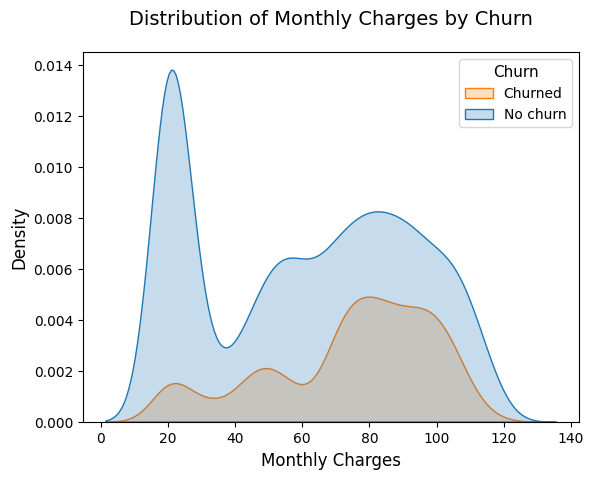

In [381]:
# Visualizing the distribution of monthly charges by churn status using a KDE plot.

ax = sns.kdeplot(data=df, x='monthly_charges', hue='churn', fill=True)

ax.legend(
    title='Churn',
    labels=['Churned', 'No churn'],
    title_fontsize=11,
    fontsize=10,
    loc='upper right'
)
ax.set_title('Distribution of Monthly Charges by Churn', fontsize=14, pad=20)
ax.set_xlabel('Monthly Charges', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.show()

Las variables relacionadas con el contrato muestran una fuerte asociación con el churn. El tipo de contrato es el factor más influyente, ya que los clientes con contratos mes a mes presentan tasas de abandono significativamente más altas en comparación con aquellos con contratos a largo plazo. El método de pago refuerza este patrón, donde los usuarios de electronic check presentan mayor churn, mientras que los pagos automáticos se asocian con mayor retención.

Asimismo, la variable paperless_billing también muestra una diferencia relevante, con mayores tasas de abandono en clientes que utilizan facturación electrónica.

En esta etapa no se analizó directamente la variable begin_date, ya que su propósito principal es ser utilizada posteriormente en la generación de variables temporales dentro de un esquema de división temporal (time-based split). Dado que parte de su información ya ha sido capturada mediante variables derivadas, su análisis individual no aporta valor adicional en esta fase.

En conjunto, la estructura del contrato y el método de pago emergen como factores clave asociados al churn y serán altamente relevantes en la fase de modelado.

### Impact of Personal details on Churn

In [382]:
# Identifying which columns in the 'personal' dataset are binary and which are non-binary.

personal_columns = set(standarize_column_names(personal)) & set(df.columns)

personal_unique = []
unique_type = []

for col in personal_columns:
    personal_unique.append([df[col].nunique(), df[col].dtypes])
    unique_type.append(', '.join(map(str, sorted(df[col].unique(), reverse=True))))

df_personal_info = pd.DataFrame(personal_unique, columns=['Unique Values', 'Data Type'], index=list(personal_columns))
df_personal_info['Unique Values List'] = unique_type

df_personal_info.sort_values('Unique Values', ascending=False)

,Unique Values,Data Type,Unique Values List
partner,2,str,"Yes, No"
dependents,2,str,"Yes, No"
senior_citizen,2,int64,"1, 0"
gender,2,str,"Male, Female"


In [383]:
# Analyzing the relationship between binary features and the target variable 'churn'.

binary_personal = personal_columns & set(binary_columns)

for col in binary_personal:
    dist = df.groupby(col)['churn'].mean()
    dist = dist.sort_index()
    dist = dist.map(lambda x: f"{x:.1%}")

    display_df = pd.DataFrame(dist.values, columns=[
                              'Proportion'], index=dist.index)

    display_df.index.name = None

    print(f"\nChurn rate for {col}:")
    display(display_df)


Churn rate for partner:


,Proportion
No,33.0%
Yes,19.7%



Churn rate for dependents:


,Proportion
No,31.3%
Yes,15.5%



Churn rate for senior_citizen:


,Proportion
0,23.6%
1,41.7%



Churn rate for gender:


,Proportion
Female,26.9%
Male,26.2%


Las variables personales muestran diferencias claras en las tasas de abandono. En particular, senior_citizen presenta una de las asociaciones más fuertes, con una tasa de abandono de ~41.7% en clientes senior, casi el doble en comparación con los no senior (~23.6%).

De manera similar, las variables dependents y partner indican que los clientes sin dependientes o sin pareja tienen una mayor probabilidad de churn. En ambos casos, la tasa de abandono de estos grupos (~31–33%) es aproximadamente el doble que la de los clientes con dependientes o pareja (~15–20%), lo que sugiere que factores asociados a estabilidad personal pueden influir en la retención.

En contraste, la variable gender se encuentra prácticamente balanceada entre clases, sin diferencias relevantes en las tasas de churn, por lo que su poder predictivo esperado es limitado.

### Impact of Phone Services and Temporal Features on Churn

In [384]:
# Identifying the last columns that belong to the 'phone' dataset and Temporal features created from 'begin_date'.

last_columns = set(df.columns) - personal_columns - internet_columns - contract_columns - {'churn'}

last_unique = []

for col in last_columns:
    last_unique.append([df[col].nunique(), df[col].dtypes])

df_phone_info = pd.DataFrame(last_unique, columns=[
                                'Unique Values', 'Data Type'], index=list(last_columns))

df_phone_info.sort_values('Unique Values', ascending=False)

,Unique Values,Data Type
start_month,12,int32
start_year,8,int32
multiple_lines,2,str


In [385]:
# Analyzing categorical features in the dataset 'phone' and the Tenure group feature.

for col in last_columns:
    dist = df.groupby(col)['churn'].mean()
    dist = dist.sort_index()
    dist = dist.map(lambda x: f"{x:.1%}")

    display_df = pd.DataFrame(dist.values, columns=[
                              'Proportion'], index=dist.index)

    display_df.index.name = None

    print(f"\nChurn rate for {col}:")
    display(display_df)


Churn rate for start_month:


,Proportion
1,15.1%
2,15.2%
3,18.1%
4,19.2%
5,25.5%
6,25.3%
7,27.4%
8,28.4%
9,41.3%
10,35.3%



Churn rate for multiple_lines:


,Proportion
No,25.0%
Yes,28.6%



Churn rate for start_year:


,Proportion
2013,100.0%
2014,7.3%
2015,14.4%
2016,19.0%
2017,23.6%
2018,30.6%
2019,50.1%
2020,0.0%


Las variables analizadas muestran patrones relevantes en relación con el churn, especialmente aquellas asociadas al momento de adquisición del cliente.

En start_month se observa variabilidad a lo largo del año, con mayores tasas de abandono en meses recientes, lo que sugiere posibles efectos estacionales. Por su parte, start_year evidencia un fuerte efecto de cohorte, donde los clientes más recientes presentan mayor churn, lo que podría estar capturando indirectamente la antigüedad.

En contraste, multiple_lines muestra un impacto limitado en las tasas de abandono. Asimismo, se evaluó una variable is_weekend, construida a partir del día de la semana de begin_date, la cual no mostró diferencias significativas en el churn, lo que confirma su bajo poder explicativo y justifica su exclusión del modelado.

En conjunto, las variables temporales parecen ser más relevantes que las relacionadas con servicios telefónicos, aunque su uso debe evaluarse con cautela, ya que pueden capturar indirectamente la antigüedad del cliente.

# Key Insights Summary

El análisis exploratorio identifica varios factores clave fuertemente asociados con el abandono de clientes, destacando patrones de comportamiento claros entre segmentos de clientes:

1. La permanencia del cliente es el impulsor más fuerte del abandono, con clientes nuevos mostrando tasas de abandono significativamente más altas (~54% en los primeros 6 meses), que disminuyen constantemente a medida que aumenta la permanencia. Esto indica que el riesgo de abandono es más alto al inicio del ciclo de vida del cliente.

2. El tipo de contrato juega un papel crítico, ya que los clientes con planes mes a mes exhiben un abandono sustancialmente más alto comparado con aquellos con contratos a largo plazo, sugiriendo que el nivel de compromiso impacta directamente la retención.

3. Las características relacionadas con servicios son predictores fuertes, particularmente la ausencia de servicios como online_security y tech_support, que está asociada con tasas de abandono notablemente más altas.

4. El tipo de servicio de internet muestra un patrón claro, con clientes de fibra óptica teniendo el abandono más alto, potencialmente reflejando diferencias en precios, expectativas, o experiencia de servicio.

5. El precio es un factor importante, ya que cargos mensuales más altos están asociados con mayor abandono. En contraste, los clientes con cargos mensuales bajos (~$20/mes) rara vez abandonan, indicando una retención fuerte en niveles de precio más bajos.

6. Las características temporales derivadas de begin_date revelan patrones adicionales relevantes. start_year muestra un fuerte efecto de cohorte, donde los clientes más recientes presentan mayores tasas de churn. Sin embargo, algunos valores extremos, como el 100% de churn en 2013, probablemente se deben a un tamaño de muestra reducido, por lo que deben interpretarse con cautela. Por su parte, start_month sugiere posibles variaciones estacionales en la adquisición de clientes. En conjunto, estos resultados indican que el momento de incorporación del cliente puede influir en su probabilidad de abandono.

7. Las características personales también contribuyen, con clientes sin parejas o dependientes, así como clientes mayores, mostrando tasas de abandono más altas, sugiriendo que factores relacionados con estabilidad pueden influir en la retención.

8. Algunas características muestran impacto limitado, como género y líneas múltiples, que exhiben diferencias mínimas en tasas de abandono y se espera que tengan bajo poder predictivo.

En general, el abandono parece estar impulsado por una combinación de etapa del ciclo de vida del cliente, estructura de contrato, adopción de servicios, momento de adquisición y precios, proporcionando una base sólida para construir modelos predictivos e informar estrategias de retención.

# Feature Engineering based on patterns identified in EDA

In [386]:
# Feature engineering to create new features that capture important aspects of customer behavior and contract characteristics, which may enhance the predictive power of the model.

service_cols = set(df.columns) & set(standarize_column_names(internet)) | {'multiple_lines'}

df['monthly_contract'] = (df['type'] == 'Month-to-month').astype(int)

df['num_services'] = (df[list(service_cols)] == 'Yes').sum(axis=1)

df['services_x_monthly'] = df['num_services'] * df['monthly_contract']

Se crearon nuevas variables basadas en los hallazgos del análisis exploratorio, con el objetivo de capturar comportamientos relevantes de los clientes y características del servicio.

En particular, se generó la variable monthly_contract para identificar clientes con contratos mes a mes, representando su nivel de compromiso, así como num_services, que cuantifica el grado de adopción de servicios y refleja el nivel de integración del cliente con la compañía.

Adicionalmente, se construyó la variable services_x_monthly, que captura la interacción entre el tipo de contrato y la cantidad de servicios, permitiendo identificar perfiles de mayor riesgo, como clientes con múltiples servicios y baja permanencia contractual.

Estas transformaciones permiten representar patrones de comportamiento de forma más generalizable, facilitando que los modelos identifiquen relaciones relevantes sin depender explícitamente de la variable objetivo.

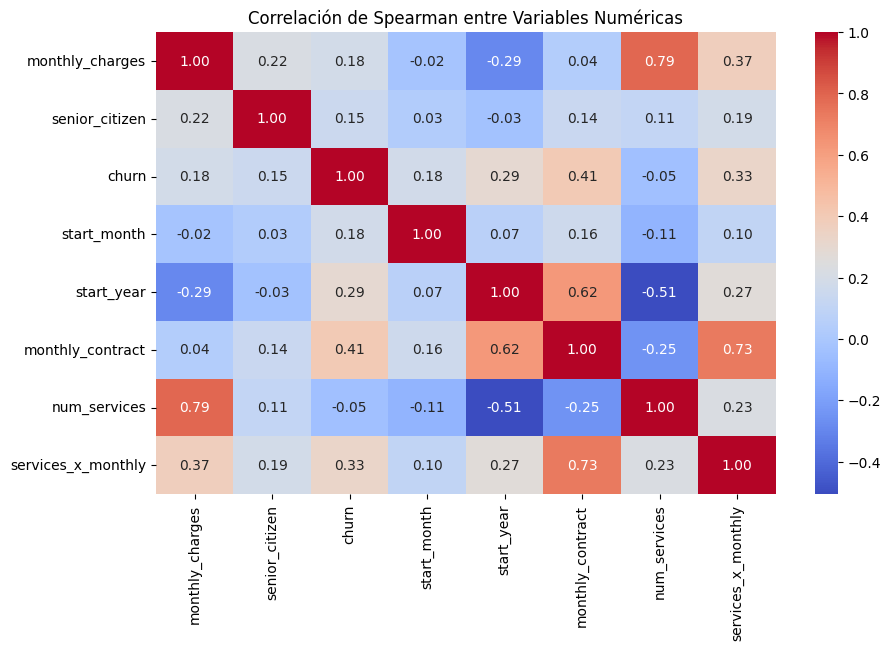

In [387]:
# Correlation check to avoid multicollinearity issues in the modeling phase.

plt.figure(figsize=(10, 6))
sns.heatmap(df[df.select_dtypes(include=['float64', 'int64', 'int32']).columns].corr(method='spearman'),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Spearman entre Variables Numéricas')
plt.show()


El análisis de correlación revela relaciones relevantes entre las variables numéricas. En particular, se observa una alta correlación entre monthly_charges y num_services, lo que indica que ambas variables capturan información relacionada con el nivel de consumo del cliente.

Asimismo, services_x_monthly presenta una alta correlación con monthly_contract, lo cual es esperable al tratarse de una variable derivada. Sin embargo, su correlación moderada con churn sugiere que esta interacción logra capturar información adicional relevante más allá de sus componentes individuales.

Por otro lado, start_year muestra una correlación moderada tanto con churn como con monthly_contract, lo que refuerza la existencia de un efecto de cohorte y sugiere que esta variable puede estar capturando indirectamente la antigüedad del cliente.

En cuanto a la variable objetivo, monthly_contract continúa mostrando la relación más fuerte con churn, confirmando su relevancia como uno de los principales factores explicativos del abandono.

Dado lo anterior, se tendrá en cuenta la posible redundancia entre variables altamente correlacionadas. No obstante, en modelos basados en árboles, estas relaciones no representan un problema significativo, ya que dichos modelos pueden manejar variables correlacionadas de forma eficiente.

In [388]:
# Converting binary and low-cardinality categorical columns to 'category' data type for memory efficiency.

category_columns = (set(df_categorical_dist[df_categorical_dist['Unique Values']
                    < 13]['Unique Values'].index) | set(binary_columns)) | {'monthly_contract', 'num_services', 'services_x_monthly'}

for col in category_columns:
    df[col] = df[col].astype('category')

In [389]:
df.dtypes

begin_date            datetime64[us]
type                        category
paperless_billing           category
payment_method              category
monthly_charges              float64
internet_service            category
online_security             category
online_backup               category
device_protection           category
tech_support                category
streaming_tv                category
streaming_movies            category
gender                      category
senior_citizen              category
partner                     category
dependents                  category
multiple_lines              category
churn                       category
start_month                 category
start_year                  category
monthly_contract            category
num_services                category
services_x_monthly          category
dtype: object

# Time-Based Train/Test Split

In [390]:
# Splitting the dataset by time: training on past data and testing on future data to simulate real-world performance.

df = df.sort_values('begin_date')

split_index = int(len(df) * 0.8)

X = df.drop('churn', axis=1)
y = df['churn']

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Time-Aware Feature Engineering: Tenure-Based Features

In [391]:
# Create tenure features using separate reference dates to avoid data leakage.

train_reference_date = X_train['begin_date'].max() + pd.Timedelta(days=1)
test_reference_date = X_test['begin_date'].max() + pd.Timedelta(days=1)


X_train['tenure_days'] = (train_reference_date - X_train['begin_date']).dt.days
X_test['tenure_days'] = (test_reference_date - X_test['begin_date']).dt.days


bins = [-1, 180, 365, 730, float('inf')]
labels = ['0-6m', '6-12m', '1-2y', '2y+']

X_train['tenure_group'] = pd.cut(
    X_train['tenure_days'], bins=bins, labels=labels)
X_test['tenure_group'] = pd.cut(
    X_test['tenure_days'], bins=bins, labels=labels)


X_train = X_train.drop(columns=['begin_date'])
X_test = X_test.drop(columns=['begin_date'])

En esta etapa se implementó una división temporal del dataset, entrenando el modelo con datos históricos y evaluándolo sobre observaciones futuras, con el objetivo de simular un escenario real de predicción y evitar fuga de información.

A partir de esta división, se generaron variables de antigüedad (tenure) utilizando fechas de referencia independientes para los conjuntos de entrenamiento y prueba, asegurando que cada cálculo se base únicamente en información disponible en su respectivo contexto temporal.

Cabe destacar que la variable total_charges fue excluida del análisis, ya que su naturaleza acumulativa incorpora información futura que no estaría disponible en el momento de la predicción, incluso bajo un esquema de división temporal, lo que la convierte en una fuente potencial de fuga de datos.

# Categorical Encoding Pipeline

In [462]:

binary_cols = [
    'dependents', 'device_protection', 'gender', 'monthly_contract',
    'multiple_lines', 'online_backup', 'online_security', 'paperless_billing',
    'partner', 'senior_citizen', 'streaming_movies', 'streaming_tv',
    'tech_support',
]

categorical_cols = [
    'internet_service', 'num_services', 'payment_method', 'services_x_monthly',
    'start_month', 'start_year', 'tenure_group', 'type',
]

categorical_cols_linear = [f for f in categorical_cols if f not in ['tenure_group', 'services_x_monthly']]

numerical_cols = ['monthly_charges', 'tenure_days']


preprocessor_linear = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_cols),
                  ('bin', OrdinalEncoder(handle_unknown='use_encoded_value',
                   unknown_value=-1), binary_cols),
                  ('multi', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_linear)],
    remainder='drop'
)

preprocessor_tree = ColumnTransformer(
    transformers=[('multi', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
                  ('bin', OrdinalEncoder(handle_unknown='use_encoded_value',
                   unknown_value=-1), binary_cols),
                  ('num_pass',  'passthrough', numerical_cols)],
    remainder='drop'
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_cols + categorical_cols),
                  ('num', 'passthrough', numerical_cols)],
    remainder='drop'
)

Se definieron pipelines de preprocesamiento específicos para cada tipo de modelo, adaptando la codificación de variables categóricas y el tratamiento de variables numéricas según sus características.

Para modelos lineales, se aplicó estandarización a variables numéricas y codificación one-hot a variables categóricas, evitando variables altamente correlacionadas para reducir problemas de multicolinealidad. En modelos basados en árboles, se permitió el uso de variables correlacionadas y se emplearon codificaciones más flexibles, dado que estos modelos son capaces de manejar relaciones no lineales y redundancias de forma eficiente.

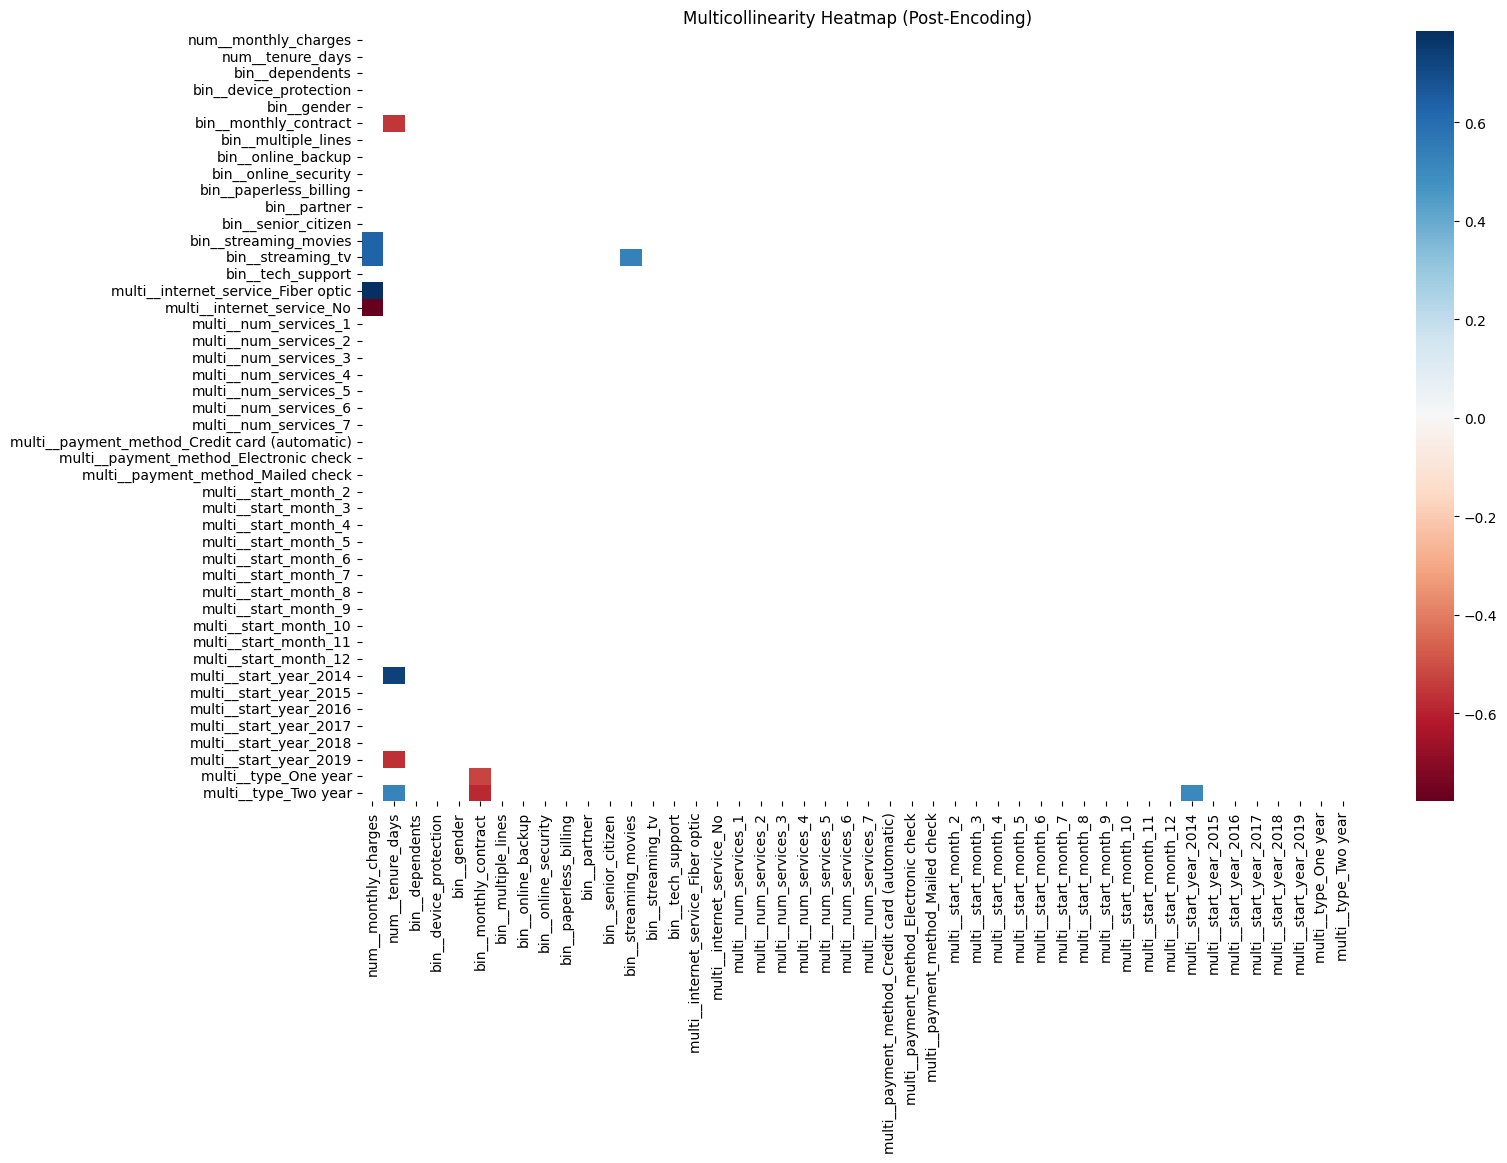

Top 10 Highly Correlated Pairs:
num__monthly_charges   multi__internet_service_Fiber optic    0.784847
                       multi__internet_service_No             0.779448
num__tenure_days       multi__start_year_2014                 0.734472
num__monthly_charges   bin__streaming_tv                      0.635430
                       bin__streaming_movies                  0.634796
bin__monthly_contract  multi__type_Two year                   0.587356
num__tenure_days       multi__start_year_2019                 0.571142
                       bin__monthly_contract                  0.558574
bin__streaming_movies  bin__streaming_tv                      0.530588
bin__monthly_contract  multi__type_One year                   0.528582
dtype: float64


In [ ]:
# Verifying multicollinearity after encoding to identify highly correlated features above 0.5 that may harm the performance of Logistic Regression.

X_processed = preprocessor_linear.fit_transform(X_train)

feature_names = preprocessor_linear.get_feature_names_out()

df_corr = pd.DataFrame(X_processed, columns=feature_names)

plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr()[df_corr.corr().abs() >
            0.5], mask=mask, cmap='RdBu', center=0)
plt.title('Multicollinearity Heatmap (Post-Encoding)')
plt.show()

corr_matrix = df_corr.corr().abs()
high_corr = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))

print("Top 10 Highly Correlated Pairs:")
print(high_corr.head(10))

Tras codificar las variables, se realizó un análisis de multicolinealidad para asegurar la estabilidad de la Regresión Logística, dado que los modelos lineales son sensibles a la redundancia. Se eliminó la variable tenure_group al presentar una correlación crítica superior a 0.85 con tenure_days, priorizando la variable numérica por su mayor precisión. 

Asimismo, se descartaron variables como services_x_monthly para simplificar el modelo. Respecto al par monthly_charges e internet_service_Fiber optic, se decidió mantener ambos a pesar de su correlación de 0.78. Esta decisión se justifica porque, aunque están relacionados, capturan señales distintas: mientras que los cargos mensuales reflejan el impacto del costo total en la decisión del cliente, el indicador de fibra óptica señala si el uso de esa tecnología específica influye en el abandono (por ejemplo, por insatisfacción con el servicio técnico de fibra), independientemente del precio. Al mantenerse bajo el umbral de 0.80, el modelo puede distinguir ambos efectos sin sacrificar la fiabilidad de los coeficientes.

# Machine Learning

In [465]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterGrid

from sklearn.model_selection import TimeSeriesSplit


def train_with_search(model, param_grid,
                      X_train, X_test,
                      y_train, y_test,
                      model_name='Model',
                      fit_params=None,
                      iterations=10,
                      n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)

    total_params = len(ParameterGrid(param_grid))
    actual_iter = min(iterations, total_params)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=actual_iter,
        cv=tscv,              # ← replaces cv=5
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train, **(fit_params or {}))

    best_model = search.best_estimator_
    prediction = best_model.predict(X_test)

    cm = confusion_matrix(y_test, prediction)

    results = {
        'ROC AUC': roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]),
        'F1 Score': f1_score(y_test, prediction),
        'Accuracy': accuracy_score(y_test, prediction),
        'Log Loss': log_loss(y_test, best_model.predict_proba(X_test)[:, 1])
    }

    print(f"\nBest {model_name} Performance:")
    display(pd.DataFrame(results.values(),
            index=results.keys(), columns=['Score']))

    print("\nBest params:")
    display(pd.DataFrame(search.best_params_, index=[
            0]).T.rename(columns={0: 'Best Value'}))
    print()

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

    return results, search.best_params_, best_model

### Dummy model (baseline)

In [461]:
# Baseline model using a Dummy Classifier to establish a reference point for model performance.

import warnings
warnings.filterwarnings("ignore", message="Found unknown categories.*")

dummy_clf = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

dummy_clf.fit(X_train, y_train)

prediction_dummy = dummy_clf.predict(X_test)


dummy_metrics = {
    'ROC AUC': roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1]),
    'F1 Score': f1_score(y_test, prediction_dummy),
    'Accuracy': accuracy_score(y_test, prediction_dummy),
    'Log Loss': log_loss(y_test, dummy_clf.predict_proba(X_test)[:, 1])
}

print("\nDummy Classifier Performance:\n")
display(pd.DataFrame(dummy_metrics.values(),
        index=dummy_metrics.keys(), columns=['Score']))


Dummy Classifier Performance:



,Score
ROC AUC,0.500000
F1 Score,0.000000
Accuracy,0.529454
Log Loss,16.960214


### Logistic Regression


Best Logistic Regression Performance:


,Score
ROC AUC,0.756207
F1 Score,0.709758
Accuracy,0.668559
Log Loss,0.633370



Best params:


,Best Value
classifier__C,0.01


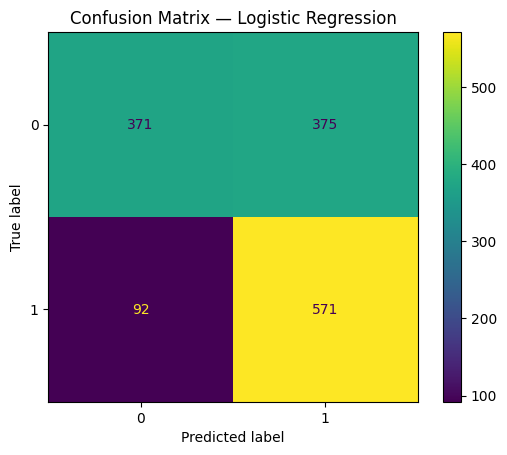

In [473]:
# Logistic Regression model pipeline with preprocessing to evaluate the predictive power of linear relationships in the data.

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('classifier', LogisticRegression(
        max_iter=3000,
        solver='saga',
        class_weight='balanced',
        random_state=42
    ))
])

logreg_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10]
}

logreg_results, logreg_params, logreg_best_model = train_with_search(
    logreg_pipeline, logreg_param_grid, X_train, X_test, y_train, y_test, "Logistic Regression", iterations=50)

Se evaluaron distintas configuraciones de regularización (L1 y L2) en la regresión logística, sin observar mejoras relevantes en el rendimiento, lo que sugiere que el modelo ya captura adecuadamente los patrones del dataset.

Asimismo, el uso de class_weight='balanced' permitió reducir significativamente los falsos negativos, aumentando la detección de clientes en riesgo. Aunque esto incrementa los falsos positivos, es un trade-off aceptable en este caso.

Por ello, se optó por una configuración simple del modelo, priorizando claridad y eficiencia sin añadir complejidad innecesaria.

### Random Forest Classifier


Best Random Forest Performance:


,Score
ROC AUC,0.746071
F1 Score,0.570144
Accuracy,0.660752
Log Loss,0.617131



Best params:


,Best Value
classifier__n_estimators,300
classifier__min_samples_split,10
classifier__min_samples_leaf,4
classifier__max_depth,10


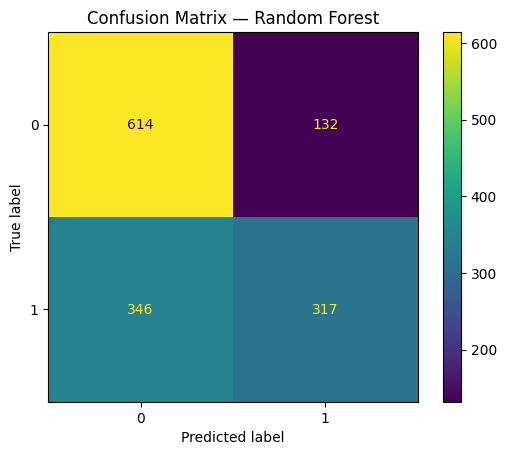

In [412]:
# Random Forest model pipeline with preprocessing to capture non-linear relationships and interactions between features.

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_results, rf_params, rf_best_model = train_with_search(
    rf_pipeline, rf_param_grid, X_train, X_test, y_train, y_test, "Random Forest", iterations=50)

### Catboost Classifier

In [410]:
# Testing CatBoost with time-series cross-validation to ensure that the model is evaluated in a way that respects the temporal order of the data and avoids data leakage.

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_folds = list(tscv.split(X_train))

cat_model = CatBoostClassifier(
    iterations=1000,
    early_stopping_rounds=50,
    cat_features=binary_cols + categorical_cols,
    verbose=0,
    random_state=42
)

cat_param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [300, 500, 800]
}

cat_results = cat_model.randomized_search(
    param_distributions=cat_param_grid,
    X=X_train,
    y=y_train,
    cv=cv_folds,        
    n_iter=50,
    partition_random_seed=42,
    verbose=False
)

print("Best params:")
display(pd.DataFrame(cat_results['params'], index=[
        0]).T.rename(columns={0: 'Best Value'}))


bestTest = 0.5541957166
bestIteration = 296

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5359401879
bestIteration = 169

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5404336069
bestIteration = 100

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5343743325
bestIteration = 194

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5297224633
bestIteration = 76


bestTest = 0.5375673992
bestIteration = 497

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5359401879
bestIteration = 169


bestTest = 0.5415419285
bestIteration = 497

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5404336069
bestIteration = 100


bestTest = 0.530539602
bestIteration = 752

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5359401879
bestIteration = 169

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5342727974
bestIteration = 85


bestTest = 0.53369

,Best Value
depth,4.0
learning_rate,0.1
l2_leaf_reg,5.0
iterations,300.0


CatBoost fue entrenado usando su implementación nativa debido a limitaciones de compatibilidad con las utilidades de búsqueda de hiperparámetros de sklearn. Se configuró early stopping con una ventana de 50 iteraciones, lo que detiene el entrenamiento automáticamente cuando el rendimiento en el conjunto de validación deja de mejorar, previniendo el sobreajuste y reduciendo el tiempo de entrenamiento innecesario.

Para la validación cruzada se utilizó TimeSeriesSplit en lugar del k-fold estándar, generando los índices de cada fold manualmente y pasándolos directamente al método randomized_search de CatBoost. Esto garantiza que en cada fold el modelo siempre entrena sobre datos anteriores y valida sobre datos posteriores, respetando el orden temporal y evitando que información futura contamine el proceso de búsqueda de hiperparámetros.


Best CatBoostClassifier Performance with reduced dataset:



,Score
ROC AUC,0.711986
F1 Score,0.566340
Accuracy,0.654365
Log Loss,0.632093


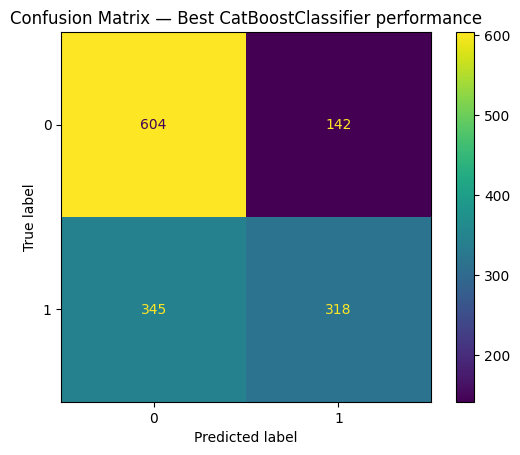

In [ ]:
# Evaluating the performance of the best CatBoost model on the test set.

cat_prediction = cat_model.predict(X_test)

cat_metrics = {
    'ROC AUC': roc_auc_score(y_test, cat_model.predict_proba(X_test)[:, 1]),
    'F1 Score': f1_score(y_test, cat_prediction),
    'Accuracy': accuracy_score(y_test, cat_prediction),
    'Log Loss': log_loss(y_test, cat_model.predict_proba(X_test)[:, 1])
}

print("\nBest CatBoostClassifier Performance with reduced dataset:\n")
results_cat = pd.DataFrame(cat_metrics.values(),
        index=cat_metrics.keys(), columns=['Score'])

display(results_cat)

cm = confusion_matrix(y_test, cat_prediction)

ConfusionMatrixDisplay(cm).plot()
plt.title(f'Confusion Matrix — Best CatBoostClassifier performance')
print()

plt.show()

### LightGBM Classifier


Best LightGBM Performance:


,Score
ROC AUC,0.718667
F1 Score,0.578901
Accuracy,0.657204
Log Loss,0.675936



Best params:


,Best Value
classifier__subsample,0.60
classifier__num_leaves,31.00
classifier__max_depth,10.00
classifier__learning_rate,0.01
classifier__colsample_bytree,0.60


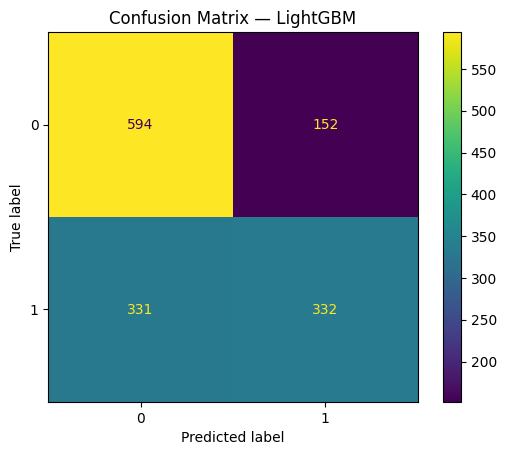

In [409]:
# LightGBM model pipeline with preprocessing to evaluate its performance and compare it with CatBoost.

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(
        objective='binary',
        n_estimators=1800,
        verbose=-1,
        random_state=42))
])

lgbm_param_grid = {
    'classifier__num_leaves': [31, 50, 100],
    'classifier__max_depth': [-1, 10, 20],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_results, lgbm_params, lgbm_best_model = train_with_search(
    lgbm_model,
    lgbm_param_grid,
    X_train,
    X_test,
    y_train,
    y_test,
    "LightGBM",
    iterations=50
)

In [1]:
# Final results recap.

comparison_df = pd.DataFrame({
    'Logistic Regression': logreg_results,
    'Random Forest': rf_results,
    'CatBoost': cat_metrics,
    'LightGBM': lgbm_results
}).T.sort_values('ROC AUC', ascending=False)

display(comparison_df)


NameError: name 'pd' is not defined

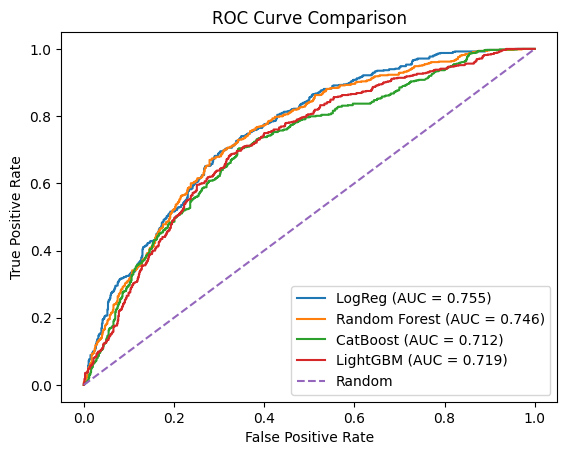

In [435]:
# Visualizing the ROC curves for all models to compare their performance in terms of true positive rate and false positive rate across different thresholds.

from sklearn.metrics import auc

y_prob_logreg = logreg_best_model.predict_proba(X_test)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

y_prob_rf = rf_best_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
auc_cat = auc(fpr_cat, tpr_cat)

y_prob_lgbm = lgbm_best_model.predict_proba(X_test)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)


plt.figure()

plt.plot(fpr_logreg, tpr_logreg, label=f'LogReg (AUC = {auc_logreg:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

In [ ]:
# Improving threshold selection for the Logistic Regression model by analyzing the precision-recall curve and identifying the threshold that maximizes the F1 score.

from sklearn.metrics import precision_recall_curve

y_proba = logreg_best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores[:-1].argmax()]

print(f"Best threshold for F1: {best_threshold:.3f}")

Best threshold for F1: 0.488


,Score
ROC AUC,0.754652
F1 Score,0.710462
Accuracy,0.662172
Log Loss,0.636227


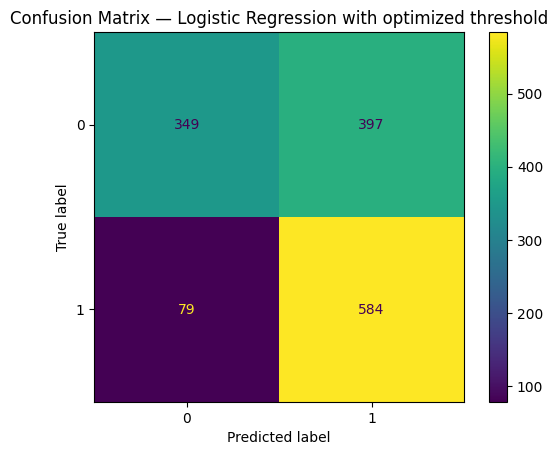

In [467]:
# Evaluating the performance of the Logistic Regression model using the optimized threshold to improve the F1 score and overall classification performance.

logreg_prediction = logreg_best_model.predict(X_test)
logreg_prediction_threshold = (y_proba >= best_threshold).astype(int)

logreg_metrics_threshold = {
    'ROC AUC': roc_auc_score(y_test, y_proba),
    'F1 Score': f1_score(y_test, logreg_prediction_threshold),
    'Accuracy': accuracy_score(y_test, logreg_prediction_threshold),
    'Log Loss': log_loss(y_test, y_proba)
}

display(pd.DataFrame(logreg_metrics_threshold.values(),
        index=logreg_metrics_threshold.keys(), columns=['Score']))

cm = confusion_matrix(y_test, logreg_prediction_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'Confusion Matrix — Logistic Regression with optimized threshold')
plt.show()

Se optimizó el umbral de clasificación mediante la curva Precision-Recall para maximizar el F1-score, logrando un umbral de 0.478 que reduce los falsos negativos a solo 79. Aunque se evaluó el estadístico de Youden's J como alternativa, este resultó en un umbral de 0.648 demasiado conservador, dejando sin detectar a 202 posibles bajas. Dado que en un contexto de churn el costo de perder un cliente es mayor al de una falsa alarma, se seleccionó el umbral optimizado por F1-score para garantizar que el equipo de retención identifique a la gran mayoría de los usuarios en riesgo.

# Conclusion 

El objetivo del proyecto fue predecir el abandono de clientes utilizando información de contratos, servicios y características del cliente.

Durante el análisis se identificó la presencia de data leakage, evidenciada por métricas inicialmente infladas. Este problema fue abordado mediante la eliminación de variables derivadas del tiempo y la implementación de un enfoque de validación basado en el tiempo, lo que permitió obtener resultados más realistas y representativos del desempeño en escenarios reales.

Tras comparar múltiples modelos bajo este enfoque, la regresión logística demostró el mejor desempeño en términos de ROC-AUC, superando ligeramente a modelos más complejos. Esto sugiere que la relación entre las variables y el churn es mayormente lineal y que el modelo logra capturar adecuadamente los patrones relevantes del dataset.

Adicionalmente, se optimizó el umbral de clasificación para maximizar el F1-score, priorizando la detección de clientes en riesgo. Este ajuste permitió reducir significativamente los falsos negativos, alineando el modelo con el objetivo de negocio, donde es preferible anticipar el abandono incluso a costa de aumentar los falsos positivos.

Finalmente, los experimentos de feature engineering no generaron mejoras significativas, lo que indica que existe un límite en la señal disponible en los datos. En conjunto, el modelo final ofrece un balance adecuado entre capacidad predictiva, interpretabilidad y aplicabilidad práctica.

# Informe de solución 

### ¿Qué pasos del plan se realizaron y qué pasos se omitieron?

Todos los pasos del plan fueron realizados exitosamente. Se implementaron pipelines de preprocesamiento específicos para cada tipo de modelo, se gestionó la multicolinealidad priorizando variables representativas, y posteriormente se incorporó una verificación explícita mediante matrices de correlación tras el encoding para identificar relaciones redundantes entre variables.

Asimismo, se optimizaron hiperparámetros mediante RandomizedSearchCV, se entrenaron múltiples modelos (incluyendo un baseline) y se evaluaron utilizando métricas como ROC AUC, F1-score, Accuracy, Log Loss, además de matrices de confusión y curvas ROC.

Adicionalmente, se incorporaron mejoras no contempladas inicialmente en el plan, como la detección y corrección de data leakage, así como la implementación de un enfoque de validación basado en el tiempo, lo que permitió obtener resultados más realistas y alineados con un escenario productivo.

### ¿Qué dificultades encontraste y cómo lograste resolverlas?

La principal dificultad fue la detección y manejo del data leakage en variables relacionadas con la antigüedad del cliente. Inicialmente, variables como tenure_days y tenure_group generaban métricas infladas al capturar indirectamente información del futuro cuando se utilizaba una división aleatoria de los datos.

Para resolverlo, se adoptó un enfoque de validación basado en el tiempo (time-based split y validación cruzada temporal), lo que permitió calcular estas variables de forma consistente con un escenario real y eliminar el sesgo en la evaluación. Este cambio implicó una reducción en el rendimiento de los modelos, pero resultó en métricas más realistas y confiables.

Adicionalmente, se identificó la necesidad de controlar la multicolinealidad en modelos lineales. Para ello, se realizó un análisis de correlación posterior al encoding, permitiendo detectar relaciones redundantes entre variables y ajustar la selección de features para mejorar la estabilidad del modelo.

Finalmente, se presentaron desafíos técnicos en la integración de distintos modelos dentro de un mismo esquema de validación temporal. En particular, CatBoost requirió el uso de su método nativo de búsqueda de hiperparámetros para adaptarse correctamente a este enfoque.

### ¿Cuáles fueron algunos de los pasos clave para resolver la tarea?

Los pasos más determinantes para resolver la tarea fueron los siguientes:

En primer lugar, la adopción de un enfoque de validación basado en el tiempo fue clave para garantizar que los resultados fueran realistas. Este cambio permitió evitar data leakage y simular de manera adecuada un escenario de predicción en producción.

En segundo lugar, la selección y transformación de variables basada en el análisis exploratorio resultó fundamental. Si bien se crearon nuevas características a partir de los patrones identificados, se observó que agregar variables adicionales no siempre mejoraba el rendimiento, lo que sugiere que los modelos ya capturaban gran parte de la señal disponible.

Asimismo, el uso de preprocesadores diferenciados por tipo de modelo permitió aprovechar las fortalezas de cada algoritmo, aplicando técnicas de encoding y escalado específicas para modelos lineales, árboles y gradient boosting.

Adicionalmente, el control de la multicolinealidad mediante análisis de correlación posterior al encoding contribuyó a mejorar la estabilidad de la regresión logística, evitando redundancias innecesarias entre variables.

Finalmente, la implementación de una función personalizada para la búsqueda de hiperparámetros y evaluación con validación temporal permitió estructurar el proceso de entrenamiento de forma consistente y reproducible.

### ¿Cuál es tu modelo final y qué nivel de calidad tiene?

El modelo final seleccionado es Regresión Logística, ya que obtuvo el mejor desempeño global con un ROC AUC de 0.75, superando claramente a Random Forest (0.74), LightGBM (0.72) y CatBoost (0.71).

Adicionalmente, se optimizó el umbral de clasificación mediante la curva Precision-Recall para maximizar el F1-score, obteniendo un valor de 0.478. Este ajuste permitió mejorar la detección de clientes en riesgo, reduciendo los falsos negativos a solo 79 casos.

Se evaluó también el uso del estadístico de Youden’s J, pero este produjo un umbral más conservador (0.648), dejando sin detectar una cantidad considerablemente mayor de abandonos. Dado que en un contexto de negocio el costo de no identificar a un cliente en riesgo es mayor que el de una falsa alarma, se priorizó el umbral optimizado por F1-score.

En conjunto, el modelo presenta un rendimiento sólido y balanceado, con especial énfasis en la detección de clientes con alta probabilidad de abandono, lo que lo hace adecuado para apoyar estrategias de retención.